In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Load & Clean Data
df = pd.read_csv("irs_soi.csv")

df = df[['agi_stub', 'N1', 'A00100']].dropna()
df.columns = ['income_group', 'returns', 'total_income']

# Remove invalid values
df = df[(df['returns'] > 0) & (df['total_income'] > 0)]

In [13]:
#Feature Engineering
df['avg_income'] = df['total_income'] / df['returns']
df = df.sort_values(by='avg_income')

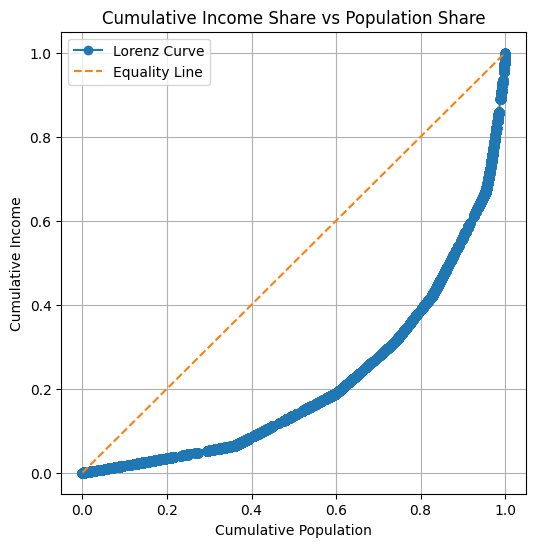

In [23]:
#Cumulative Income Share vs Population Share - Lorenz Curve.

# Population share
pop_share = df['returns'] / df['returns'].sum()

# Income share
income_share = df['total_income'] / df['total_income'].sum()

# Cumulative values
cum_pop = np.cumsum(pop_share)
cum_income = np.cumsum(income_share)

# Add starting point (0,0)
cum_pop = np.insert(cum_pop, 0, 0)
cum_income = np.insert(cum_income, 0, 0)

# Plot
plt.figure(figsize=(6,6))
plt.plot(cum_pop, cum_income, marker='o', label='Lorenz Curve')
plt.plot([0,1],[0,1], linestyle='--', label='Equality Line')

plt.xlabel("Cumulative Population")
plt.ylabel("Cumulative Income")
plt.title("Cumulative Income Share vs Population Share")
plt.legend()
plt.grid()
plt.show()

In [15]:
# Gini Coefficient
gini = 1 - 2 * np.trapz(cum_income, cum_pop)
print("Gini Coefficient:", round(gini, 3))

Gini Coefficient: 0.571


/tmp/ipykernel_8805/1352470930.py:1: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_income, cum_pop)


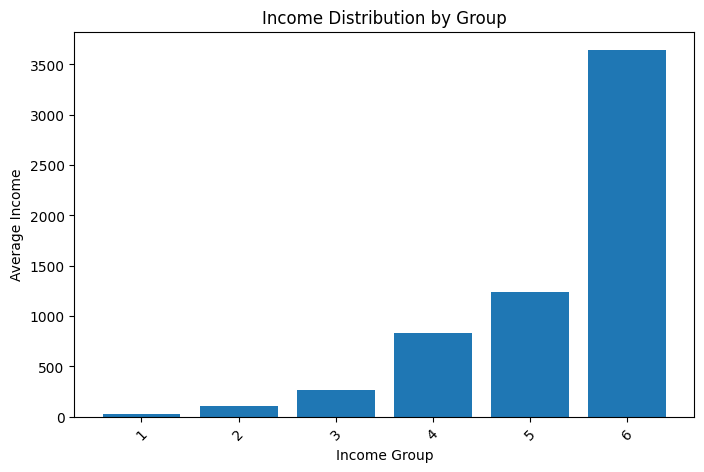

In [25]:
# Income Distribution
plt.figure(figsize=(8,5))
plt.bar(df['income_group'], df['avg_income'])

plt.xticks(rotation=45)
plt.xlabel("Income Group")
plt.ylabel("Average Income")
plt.title("Income Distribution by Group")
plt.show()

In [27]:
# Statistical Modeling
mean = df['avg_income'].mean()
median = df['avg_income'].median()
std = df['avg_income'].std()

print("Mean Income:", round(mean,2))
print("Median Income:", round(median,2))
print("Std Deviation:", round(std,2))

Mean Income: 102.19
Median Income: 62.01
Std Deviation: 128.31


In [26]:
# Income Share
df['income_share'] = df['total_income'] / df['total_income'].sum()

print(df[['income_group', 'income_share']])

        income_group  income_share
47186              1  5.068184e-08
72642              1  4.863311e-08
133562             1  2.385315e-08
3797               1  2.775550e-08
159043             1  4.321859e-08
...              ...           ...
27886              6  2.594243e-04
38029              6  2.012064e-05
15438              6  5.120279e-04
15282              6  6.075792e-05
27058              6  2.132286e-05

[159935 rows x 2 columns]


In [18]:
# Insight Output
if gini > 0.4:
    print("High income inequality observed.")
elif gini > 0.3:
    print("Moderate inequality observed.")
else:
    print("Low inequality observed.")

High income inequality observed.
